# AI-enabled antibody developability and molecular design

## Molecular Design Engineering 

This notebook demonstrates an end-to-end workflow at the interface of antibody engineering, molecular biology, predictive modelling, experimental developability assays, and decision support.

### Workflow

1. Simulate a lineage-aware panel of monoclonal, bispecific IgG-like, and scFv-fusion candidates.
2. Calculate sequence-level, CDR-level, and chemical-liability descriptors.
3. Simulate experimental developability measurements using literature-informed ranges.
4. Test format-dependent differences and multivariate relationships.
5. Train leakage-resistant classification and multi-output regression models.
6. Evaluate discrimination, calibration, uncertainty, robustness, and feature importance.
7. Design de-risked variants for a selected lead and construct a Pareto-ranked shortlist.
8. Export analysis-ready datasets, figures, model summaries, and illustrative coding sequences.

> **Scientific-use statement.** All molecule sequences and assay measurements are synthetic. Published studies are used only to define plausible ranges, relationships, and workflow choices. The output is not experimental evidence, a clinical conclusion, or a validated developability specification.

## Literature basis and benchmark anchors

The simulation is informed by peer-reviewed articles indexed in PubMed:

| Study | Contribution used here | PubMed |
|---|---|---|
| Jain et al., 2017, *PNAS* | 137 clinical-stage antibodies measured across 12 biophysical assays; motivates multidimensional developability assessment and empirical risk boundaries | PMID: [28096333](https://pubmed.ncbi.nlm.nih.gov/28096333/) |
| Raybould et al., 2019, *PNAS* | Therapeutic Antibody Profiler, including CDR length, hydrophobicity, charge asymmetry, and CDR charge guidelines | PMID: [30765520](https://pubmed.ncbi.nlm.nih.gov/30765520/) |
| Lauer et al., 2012, *Journal of Pharmaceutical Sciences* | Sequence/structure-derived developability index for aggregation propensity | PMID: [21935950](https://pubmed.ncbi.nlm.nih.gov/21935950/) |
| Jetha et al., 2018, *mAbs* | Structure-guided mutation and HIC used to improve antibody developability | PMID: [30110240](https://pubmed.ncbi.nlm.nih.gov/30110240/) |
| Bailly et al., 2020, *mAbs* | High-throughput early developability workflow for ranking hundreds to thousands of molecules | PMID: [32249670](https://pubmed.ncbi.nlm.nih.gov/32249670/) |
| Zhang et al., 2020, *Molecular Pharmaceutics* | Physicochemical rules for identifying antibodies with drug-like specificity | PMID: [32453957](https://pubmed.ncbi.nlm.nih.gov/32453957/) |
| Grinshpun et al., 2021, *mAbs* | Experimental and in silico properties associated with slower antibody clearance | PMID: [34116620](https://pubmed.ncbi.nlm.nih.gov/34116620/) |
| Datta-Mannan et al., 2022, *mAbs* | Pharmacokinetic developability and disposition diversity among bispecific antibodies | PMID: [35076469](https://pubmed.ncbi.nlm.nih.gov/35076469/) |
| Park et al., 2024, *mAbs* | Molecular surface descriptors benchmarked against viscosity, aggregation, HIC, clearance, heparin retention, and polyspecificity | PMID: [38853585](https://pubmed.ncbi.nlm.nih.gov/38853585/) |
| Condado-Morales et al., 2024, *mAbs* | Comparative developability of full-length antibodies and complex formats | PMID: [39364796](https://pubmed.ncbi.nlm.nih.gov/39364796/) |

### Didactic benchmark ranges

These are broad, approximate ranges chosen to reproduce plausible early-discovery behaviour, not acceptance criteria copied from a single paper.

| Measurement | Simulated region | Unfavourable direction |
|---|---:|---|
| Transient expression titre | 0.05–4.2 g/L | Lower |
| Apparent thermal transition | 54–83 °C | Lower |
| HIC retention | 3.5–18.5 min | Higher |
| PSR-like polyspecificity score | 0–1 | Higher |
| AC-SINS wavelength shift | 0–15 nm | Higher |
| Diffusion interaction parameter, kD | −38 to +36 mL/g | More negative |
| Viscosity at high concentration | 2–48 mPa·s | Higher |
| SEC monomer after stress | 81–100% | Lower |
| Binding affinity, KD | 0.03–300 nM | Higher, context dependent |

All thresholds below are **screening heuristics**. Real project decisions require assay controls, formulation context, molecular format, target biology, intended dose, route of administration, and experimental validation.

In [69]:
from __future__ import annotations

import json
import math
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_curve,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 20260729
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("antibody_design_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def save_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()

print(f"Random seed: {RANDOM_SEED}")
print(f"Outputs: {OUTPUT_DIR.resolve()}")

Random seed: 20260729
Outputs: /Users/petalc01/Antibody design/antibody_design_outputs


## 1. Simulate related antibody candidates

The library contains related variants derived from shared parent molecules. Random row splitting would place near-identical variants in both training and test data, so later validation splits by `parent_id`.

The architecture classes are conventional IgG1, common-light-chain IgG-like bispecific, and scFv fusion. The variable-domain strings are illustrative rather than germline-reconstructed sequences.

In [71]:
AMINO_ACIDS = np.array(list("ACDEFGHIKLMNPQRSTVWY"))
BACKGROUND_P = np.array([
    0.075, 0.018, 0.052, 0.063, 0.040,
    0.073, 0.022, 0.058, 0.067, 0.095,
    0.024, 0.044, 0.052, 0.049, 0.058,
    0.079, 0.057, 0.068, 0.013, 0.031,
])
BACKGROUND_P = BACKGROUND_P / BACKGROUND_P.sum()

HYDROPHOBIC = set("AVILMFWY")
AROMATIC = set("FWY")
POSITIVE = set("KRH")
NEGATIVE = set("DE")
POLAR_SAFE = np.array(list("STNQDEGA"))

FORMAT_LEVELS = ["IgG1", "common_light_chain_bsAb", "scFv_fusion"]
FORMAT_PROBS = [0.56, 0.25, 0.19]

def weighted_aa_prob(risk_propensity: float, cdr: bool = False) -> np.ndarray:
    p = BACKGROUND_P.copy()
    if cdr:
        for aa in "FWYILVM":
            p[np.where(AMINO_ACIDS == aa)[0][0]] *= 1.0 + 1.5 * risk_propensity
        for aa in "KR":
            p[np.where(AMINO_ACIDS == aa)[0][0]] *= 1.0 + 0.9 * risk_propensity
        for aa in "STNQ":
            p[np.where(AMINO_ACIDS == aa)[0][0]] *= 1.25 - 0.35 * risk_propensity
    return p / p.sum()

def random_sequence(length: int, risk_propensity: float = 0.3, cdr: bool = False) -> str:
    return "".join(rng.choice(AMINO_ACIDS, size=length, p=weighted_aa_prob(risk_propensity, cdr)))

def mutate_sequence(seq: str, n_mutations: int, risk_propensity: float) -> str:
    chars = list(seq)
    positions = rng.choice(len(chars), size=min(n_mutations, len(chars)), replace=False)
    p = weighted_aa_prob(risk_propensity, cdr=True)
    for pos in positions:
        mask = AMINO_ACIDS != chars[pos]
        choices = AMINO_ACIDS[mask]
        probs = p[mask]
        chars[pos] = rng.choice(choices, p=probs / probs.sum())
    return "".join(chars)

def assemble_variable_domain(fr1_len, cdr1_len, fr2_len, cdr2_len, fr3_len, cdr3, fr4_len, risk):
    return (
        random_sequence(fr1_len, risk * 0.35)
        + random_sequence(cdr1_len, risk, cdr=True)
        + random_sequence(fr2_len, risk * 0.35)
        + random_sequence(cdr2_len, risk, cdr=True)
        + random_sequence(fr3_len, risk * 0.35)
        + cdr3
        + random_sequence(fr4_len, risk * 0.35)
    )

records = []
n_parents = 180
variants_per_parent = 4

for parent_index in range(n_parents):
    parent_id = f"P{parent_index + 1:03d}"
    molecular_format = rng.choice(FORMAT_LEVELS, p=FORMAT_PROBS)
    risk_propensity = float(rng.beta(2.0, 3.6))
    hidden_process_risk = float(rng.normal(0, 0.75))

    format_length_effect = {"IgG1": 0, "common_light_chain_bsAb": 2, "scFv_fusion": 3}[molecular_format]
    cdrh3_len_a = int(np.clip(round(rng.normal(13.5 + 5.0 * risk_propensity + format_length_effect, 2.8)), 7, 27))
    cdrh3_a = random_sequence(cdrh3_len_a, risk_propensity, cdr=True)

    if molecular_format == "IgG1":
        cdrh3_b = cdrh3_a
    else:
        cdrh3_len_b = int(np.clip(round(rng.normal(14.5 + 4.5 * risk_propensity, 3.0)), 7, 28))
        cdrh3_b = random_sequence(cdrh3_len_b, min(1.0, risk_propensity + 0.08), cdr=True)

    vh_a = assemble_variable_domain(25, 8, 17, 8, 30, cdrh3_a, 11, risk_propensity)
    vl_cdr3 = random_sequence(int(rng.integers(8, 13)), risk_propensity, True)
    vl = assemble_variable_domain(23, 7, 15, 7, 31, vl_cdr3, 10, risk_propensity)
    vh_b = vh_a if molecular_format == "IgG1" else assemble_variable_domain(25, 8, 17, 8, 30, cdrh3_b, 11, risk_propensity)
    base_log_kd = rng.normal(np.log10(2.5), 0.62)

    for variant_number in range(variants_per_parent):
        n_mut = 0 if variant_number == 0 else int(rng.integers(1, 5))
        variant_risk = float(np.clip(risk_propensity + rng.normal(0, 0.08), 0, 1))
        va = mutate_sequence(cdrh3_a, n_mut, variant_risk) if n_mut else cdrh3_a
        vb = cdrh3_b if molecular_format == "IgG1" else mutate_sequence(cdrh3_b, max(0, n_mut - 1), variant_risk)
        vh_a_v = vh_a.replace(cdrh3_a, va, 1)
        vh_b_v = vh_a_v if molecular_format == "IgG1" else vh_b.replace(cdrh3_b, vb, 1)

        records.append({
            "candidate_id": f"{parent_id}_V{variant_number}",
            "parent_id": parent_id,
            "variant_number": variant_number,
            "molecular_format": molecular_format,
            "vh_a": vh_a_v,
            "vh_b": vh_b_v,
            "vl": vl,
            "cdrh3_a": va,
            "cdrh3_b": vb,
            "n_parent_mutations": n_mut,
            "risk_propensity_latent": variant_risk,
            "hidden_process_risk": hidden_process_risk + rng.normal(0, 0.25),
            "base_log10_kd": base_log_kd + rng.normal(0, 0.15 + 0.03 * n_mut),
        })

seq_df = pd.DataFrame(records)
print(f"{len(seq_df)} candidates from {seq_df['parent_id'].nunique()} parent lineages")
seq_df.head()

720 candidates from 180 parent lineages


,candidate_id,parent_id,variant_number,molecular_format,vh_a,vh_b,vl,cdrh3_a,cdrh3_b,n_parent_mutations,risk_propensity_latent,hidden_process_risk,base_log10_kd
0,P001_V0,P001,0,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SKVKGLLLLISVLVTL,SKVKGLLLLISVLVTL,0,0.591858,0.370850,0.517785
1,P001_V1,P001,1,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SKVKGRLLLISVLVTR,SKVKGLLLLISVLVTL,2,0.449676,0.270154,0.484725
2,P001_V2,P001,2,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,FKVKGLLLLISVLVML,SKVKGLLLLISVLVTL,2,0.507021,0.526321,1.060348
3,P001_V3,P001,3,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SLVAGLLLLISVFATL,SKVKGLLLLISVLVTL,4,0.483215,-0.192813,0.769415
4,P002_V0,P002,0,scFv_fusion,SVEDKFNLYNEIITGEAASVSHAAQLPWKKPIIRAKLRIIGAKGAL...,VFGSVPPSYIRQRVVFGHPTLGLPFPFAWCPKPIEGIKFPSYKIFT...,INWVVSCYGDMRAKKDKTDVGSSPERLKHTETEFGLDERERPDADS...,LKSTKFSAADGWNLS,LDELFGQFNLSVY,0,0.139122,0.150308,0.989137


## 2. Calculate interpretable sequence and liability descriptors

The feature set combines TAP-like dimensions with simple chemical-liability motifs. Motif counts are intentionally simplified and do not account for solvent exposure, structural context, formulation, or antibody numbering.

In [73]:
def fraction(seq: str, residues: set[str]) -> float:
    return sum(aa in residues for aa in seq) / max(len(seq), 1)

def longest_run(seq: str, residues: set[str]) -> int:
    best = current = 0
    for aa in seq:
        if aa in residues:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best

def entropy(seq: str) -> float:
    counts = np.array(list(Counter(seq).values()), dtype=float)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())

def motif_count(seq: str, motifs: list[str]) -> int:
    return sum(seq.count(motif) for motif in motifs)

def glyco_motif_count(seq: str) -> int:
    return len(re.findall(r"N[^P][ST]", seq))

def sequence_descriptors(row: pd.Series) -> dict:
    chains = row["vh_a"] + row["vh_b"] + row["vl"]
    cdr = row["cdrh3_a"] + row["cdrh3_b"]
    vh_charge = fraction(row["vh_a"], POSITIVE) - fraction(row["vh_a"], NEGATIVE)
    vl_charge = fraction(row["vl"], POSITIVE) - fraction(row["vl"], NEGATIVE)
    deamidation = motif_count(chains, ["NG", "NS", "NN", "NT"])
    isomerization = motif_count(chains, ["DG", "DS", "DT"])
    oxidation = chains.count("M") + chains.count("W")
    glyco = glyco_motif_count(chains)
    odd_cys = int(chains.count("C") % 2 == 1)

    return {
        "sequence_length": len(chains),
        "cdrh3_mean_length": np.mean([len(row["cdrh3_a"]), len(row["cdrh3_b"])]),
        "cdrh3_max_length": max(len(row["cdrh3_a"]), len(row["cdrh3_b"])),
        "hydrophobic_fraction": fraction(chains, HYDROPHOBIC),
        "cdr_hydrophobic_fraction": fraction(cdr, HYDROPHOBIC),
        "aromatic_fraction": fraction(chains, AROMATIC),
        "cdr_aromatic_fraction": fraction(cdr, AROMATIC),
        "positive_fraction": fraction(chains, POSITIVE),
        "negative_fraction": fraction(chains, NEGATIVE),
        "net_charge_proxy": fraction(chains, POSITIVE) - fraction(chains, NEGATIVE),
        "absolute_charge_proxy": abs(fraction(chains, POSITIVE) - fraction(chains, NEGATIVE)),
        "vh_vl_charge_asymmetry": abs(vh_charge - vl_charge),
        "longest_hydrophobic_run": longest_run(chains, HYDROPHOBIC),
        "sequence_entropy": entropy(chains),
        "deamidation_motifs": deamidation,
        "isomerization_motifs": isomerization,
        "oxidation_sites": oxidation,
        "glycosylation_motifs": glyco,
        "odd_cysteine_warning": odd_cys,
        "total_liability_motifs": deamidation + isomerization + oxidation + glyco + odd_cys,
    }

descriptor_df = seq_df.apply(sequence_descriptors, axis=1, result_type="expand")
data = pd.concat([seq_df, descriptor_df], axis=1)
data.head()

,candidate_id,parent_id,variant_number,molecular_format,vh_a,vh_b,vl,cdrh3_a,cdrh3_b,n_parent_mutations,risk_propensity_latent,hidden_process_risk,base_log10_kd,sequence_length,cdrh3_mean_length,cdrh3_max_length,hydrophobic_fraction,cdr_hydrophobic_fraction,aromatic_fraction,cdr_aromatic_fraction,positive_fraction,negative_fraction,net_charge_proxy,absolute_charge_proxy,vh_vl_charge_asymmetry,longest_hydrophobic_run,sequence_entropy,deamidation_motifs,isomerization_motifs,oxidation_sites,glycosylation_motifs,odd_cysteine_warning,total_liability_motifs
0,P001_V0,P001,0,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SKVKGLLLLISVLVTL,SKVKGLLLLISVLVTL,0,0.591858,0.370850,0.517785,334.0,16.0,16.0,0.389222,0.625000,0.062874,0.000000,0.158683,0.095808,0.062874,0.062874,0.062291,5.0,4.020441,3.0,2.0,3.0,3.0,0.0,11.0
1,P001_V1,P001,1,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SKVKGRLLLISVLVTR,SKVKGLLLLISVLVTL,2,0.449676,0.270154,0.484725,334.0,16.0,16.0,0.377246,0.562500,0.062874,0.000000,0.170659,0.095808,0.074850,0.074850,0.044900,5.0,4.028842,3.0,2.0,3.0,3.0,0.0,11.0
2,P001_V2,P001,2,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,FKVKGLLLLISVLVML,SKVKGLLLLISVLVTL,2,0.507021,0.526321,1.060348,334.0,16.0,16.0,0.401198,0.687500,0.068862,0.031250,0.158683,0.095808,0.062874,0.062874,0.062291,6.0,4.044889,3.0,2.0,5.0,3.0,0.0,13.0
3,P001_V3,P001,3,IgG1,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,DDHFQKQSLTSKTLSTRCTEEDSQFESMLITGGLEFARISRPNTTA...,IFELTFGVQLKAALKNRSFGAKSWVVGGFLNRRSRVRSHPYVGGRV...,SLVAGLLLLISVFATL,SKVKGLLLLISVLVTL,4,0.483215,-0.192813,0.769415,334.0,16.0,16.0,0.401198,0.687500,0.068862,0.031250,0.146707,0.095808,0.050898,0.050898,0.079682,5.0,4.025065,3.0,2.0,3.0,3.0,0.0,11.0
4,P002_V0,P002,0,scFv_fusion,SVEDKFNLYNEIITGEAASVSHAAQLPWKKPIIRAKLRIIGAKGAL...,VFGSVPPSYIRQRVVFGHPTLGLPFPFAWCPKPIEGIKFPSYKIFT...,INWVVSCYGDMRAKKDKTDVGSSPERLKHTETEFGLDERERPDADS...,LKSTKFSAADGWNLS,LDELFGQFNLSVY,0,0.139122,0.150308,0.989137,328.0,14.0,15.0,0.408537,0.464286,0.091463,0.178571,0.152439,0.118902,0.033537,0.033537,0.006708,5.0,4.107223,1.0,3.0,9.0,3.0,1.0,17.0


## 3. Simulate a multidimensional experimental developability panel

The data-generating process encodes hydrophobicity, charge, CDR length, format complexity, and unobserved process effects. Hidden noise prevents sequence-only models from becoming unrealistically perfect.

In [75]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

format_penalty = data["molecular_format"].map({
    "IgG1": 0.0,
    "common_light_chain_bsAb": 0.42,
    "scFv_fusion": 0.72,
}).astype(float)

hydro_excess = np.maximum(data["cdr_hydrophobic_fraction"] - 0.34, 0)
charge_burden = data["absolute_charge_proxy"] + 1.2 * data["vh_vl_charge_asymmetry"]
liability_scaled = np.clip((data["total_liability_motifs"] - 16) / 10, -1.5, 2.5)
cdr_length_scaled = np.clip((data["cdrh3_max_length"] - 14) / 7, -1.5, 2.0)
hidden = data["hidden_process_risk"]

self_assoc_latent = (
    -0.7 + 4.8 * hydro_excess + 2.3 * charge_burden
    + 0.24 * cdr_length_scaled + 0.28 * format_penalty
    + 0.28 * hidden + rng.normal(0, 0.48, len(data))
)
poly_latent = (
    -1.55 + 3.2 * data["cdr_hydrophobic_fraction"]
    + 3.8 * data["absolute_charge_proxy"]
    + 2.1 * data["vh_vl_charge_asymmetry"]
    + 0.18 * cdr_length_scaled + 0.22 * hidden
    + rng.normal(0, 0.62, len(data))
)
aggregation_latent = (
    -1.05 + 4.2 * hydro_excess + 0.34 * liability_scaled
    + 0.52 * format_penalty + 0.42 * sigmoid(self_assoc_latent)
    + 0.25 * hidden + rng.normal(0, 0.55, len(data))
)

data["expression_g_L"] = np.clip(
    np.exp(
        0.58 - 2.1 * hydro_excess - 0.24 * liability_scaled
        - 0.62 * format_penalty - 0.18 * hidden
        + rng.normal(0, 0.34, len(data))
    ),
    0.05, 4.2,
)

data["thermal_transition_C"] = np.clip(
    72.8 - 11.0 * hydro_excess - 1.25 * liability_scaled
    - 2.4 * format_penalty - 1.05 * hidden
    + rng.normal(0, 2.15, len(data)),
    54, 83,
)

data["hic_retention_min"] = np.clip(
    4.8 + 9.5 * data["cdr_hydrophobic_fraction"]
    + 0.55 * data["longest_hydrophobic_run"]
    + 0.35 * format_penalty + 0.30 * hidden
    + rng.normal(0, 1.10, len(data)),
    3.5, 18.5,
)

data["psr_score"] = np.clip(sigmoid(poly_latent) + rng.normal(0, 0.035, len(data)), 0, 1)

data["ac_sins_shift_nm"] = np.clip(
    0.5 + 12.5 * sigmoid(self_assoc_latent) + rng.normal(0, 0.75, len(data)),
    0, 15,
)

data["csi_bli_response"] = np.clip(
    0.05 + 0.95 * sigmoid(self_assoc_latent + rng.normal(0, 0.45, len(data))),
    0, 1.2,
)

data["kD_mL_g"] = np.clip(
    30 - 65 * sigmoid(self_assoc_latent) + rng.normal(0, 5.0, len(data)),
    -38, 36,
)

data["viscosity_150mg_mPa_s"] = np.clip(
    2.2 + 41 * sigmoid(
        -1.6 - 0.095 * data["kD_mL_g"]
        + 0.62 * format_penalty + rng.normal(0, 0.35, len(data))
    ),
    2, 48,
)

data["sec_monomer_after_stress_pct"] = np.clip(
    99.6 - 15.5 * sigmoid(aggregation_latent) + rng.normal(0, 0.85, len(data)),
    81, 100,
)

data["kd_nM"] = np.clip(10 ** data["base_log10_kd"], 0.03, 300)

data["clearance_mL_day_kg"] = np.clip(
    4.0 + 18.0 * data["psr_score"]
    + 0.42 * np.maximum(data["hic_retention_min"] - 10, 0)
    + 0.55 * np.maximum(-data["kD_mL_g"], 0)
    + 2.1 * format_penalty + rng.normal(0, 3.2, len(data)),
    1.2, 65,
)

for assay, sd in {
    "hic_retention_min": 0.35,
    "psr_score": 0.025,
    "thermal_transition_C": 0.55,
}.items():
    data[f"{assay}_replicate"] = data[assay] + rng.normal(0, sd, len(data))

thresholds = {
    "low_expression": ("expression_g_L", "<", 0.50),
    "low_thermal_stability": ("thermal_transition_C", "<", 64.0),
    "high_hydrophobicity": ("hic_retention_min", ">", 12.0),
    "high_polyspecificity": ("psr_score", ">", 0.65),
    "high_self_association": ("ac_sins_shift_nm", ">", 9.0),
    "attractive_interactions": ("kD_mL_g", "<", -15.0),
    "high_viscosity": ("viscosity_150mg_mPa_s", ">", 25.0),
    "stress_aggregation": ("sec_monomer_after_stress_pct", "<", 90.0),
}

for flag, (column, direction, cutoff) in thresholds.items():
    data[flag] = data[column] < cutoff if direction == "<" else data[column] > cutoff

flag_columns = list(thresholds)
data["risk_flag_count"] = data[flag_columns].sum(axis=1)
data["high_developability_risk"] = (
    (data["risk_flag_count"] >= 3)
    | (data["psr_score"] > 0.82)
    | (data["sec_monomer_after_stress_pct"] < 85)
).astype(int)

advancement_logit = (
    2.2 - 0.62 * data["risk_flag_count"]
    - 0.22 * np.log10(data["kd_nM"] + 0.05)
    - 0.24 * format_penalty + rng.normal(0, 0.38, len(data))
)
data["simulated_progression"] = rng.binomial(1, sigmoid(advancement_logit))

display(data[[
    "candidate_id", "molecular_format", "expression_g_L", "thermal_transition_C",
    "hic_retention_min", "psr_score", "ac_sins_shift_nm", "kD_mL_g",
    "viscosity_150mg_mPa_s", "sec_monomer_after_stress_pct", "kd_nM",
    "risk_flag_count", "high_developability_risk"
]].head(10))

,candidate_id,molecular_format,expression_g_L,thermal_transition_C,hic_retention_min,psr_score,ac_sins_shift_nm,kD_mL_g,viscosity_150mg_mPa_s,sec_monomer_after_stress_pct,kd_nM,risk_flag_count,high_developability_risk
0,P001_V0,IgG1,0.980298,68.598657,12.560442,0.651488,9.563190,-21.766141,25.092080,87.062306,3.294467,6,1
1,P001_V1,IgG1,2.113195,69.696416,13.485282,0.697979,10.831169,-22.988837,31.420052,90.469997,3.052988,5,1
2,P001_V2,IgG1,0.930899,69.163402,13.963868,0.824066,12.951312,-26.994731,35.285485,89.095063,11.490735,6,1
3,P001_V3,IgG1,1.638639,71.664091,12.799975,0.435616,8.911863,-24.939739,26.940185,88.372721,5.880515,4,1
4,P002_V0,scFv_fusion,1.221187,71.620300,11.453957,0.617845,6.972568,3.594340,8.849268,93.993412,9.752979,0,0
5,P002_V1,scFv_fusion,1.169382,68.355277,13.351702,0.356739,4.598452,7.609454,6.281585,91.845935,3.072926,1,0
6,P002_V2,scFv_fusion,1.447943,70.221155,10.354532,0.505194,8.525458,-16.018700,17.338365,93.229612,3.692990,1,0
7,P002_V3,scFv_fusion,0.619992,69.875540,11.498805,0.466115,7.330177,-14.577715,14.538278,91.218536,2.597737,0,0
8,P003_V0,IgG1,1.149065,71.936982,13.592921,0.545711,6.794446,8.034513,5.420926,91.395947,1.743237,1,0
9,P003_V1,IgG1,2.333302,71.933672,10.819865,0.356850,4.487087,9.476377,6.230229,92.012207,2.069296,0,0


## 4. Data-quality checks and technical repeatability

In [77]:
assert data["candidate_id"].is_unique
assert not data.isna().any().any()
assert set(data["high_developability_risk"].unique()).issubset({0, 1})
assert data["parent_id"].nunique() == n_parents

qc_summary = pd.DataFrame({
    "metric": [
        "Candidates", "Parent lineages", "Duplicate identifiers",
        "Missing values", "High-risk prevalence", "Simulated progression rate",
    ],
    "value": [
        len(data),
        data["parent_id"].nunique(),
        data["candidate_id"].duplicated().sum(),
        int(data.isna().sum().sum()),
        data["high_developability_risk"].mean(),
        data["simulated_progression"].mean(),
    ],
})
display(qc_summary)

repeatability = []
for assay in ["hic_retention_min", "psr_score", "thermal_transition_C"]:
    x = data[assay].to_numpy()
    y = data[f"{assay}_replicate"].to_numpy()
    spearman_r, spearman_p = stats.spearmanr(x, y)
    repeatability.append({
        "assay": assay,
        "Spearman_r": spearman_r,
        "p_value": spearman_p,
        "SD_of_replicate_difference": np.std(y - x, ddof=1),
    })
repeatability_df = pd.DataFrame(repeatability)
display(repeatability_df)

,metric,value
0,Candidates,720.000000
1,Parent lineages,180.000000
2,Duplicate identifiers,0.000000
3,Missing values,0.000000
4,High-risk prevalence,0.311111
5,Simulated progression rate,0.633333


,assay,Spearman_r,p_value,SD_of_replicate_difference
0,hic_retention_min,0.977958,0.0,0.348077
1,psr_score,0.987113,0.0,0.025278
2,thermal_transition_C,0.974888,0.0,0.560718


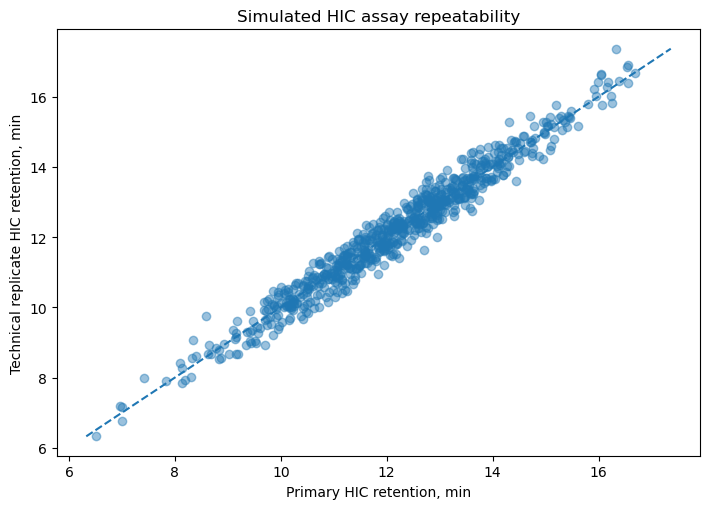

In [78]:
plt.figure(figsize=(7.2, 5.2))
plt.scatter(data["hic_retention_min"], data["hic_retention_min_replicate"], alpha=0.45)
lims = [
    min(data["hic_retention_min"].min(), data["hic_retention_min_replicate"].min()),
    max(data["hic_retention_min"].max(), data["hic_retention_min_replicate"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Primary HIC retention, min")
plt.ylabel("Technical replicate HIC retention, min")
plt.title("Simulated HIC assay repeatability")
save_figure("01_hic_repeatability.png")

High replicate agreement is expected because technical noise is small relative to between-molecule diversity. A real assay-validation programme should also quantify plate, day, operator, reagent-lot, and instrument effects.

## 5. Exploratory developability landscape

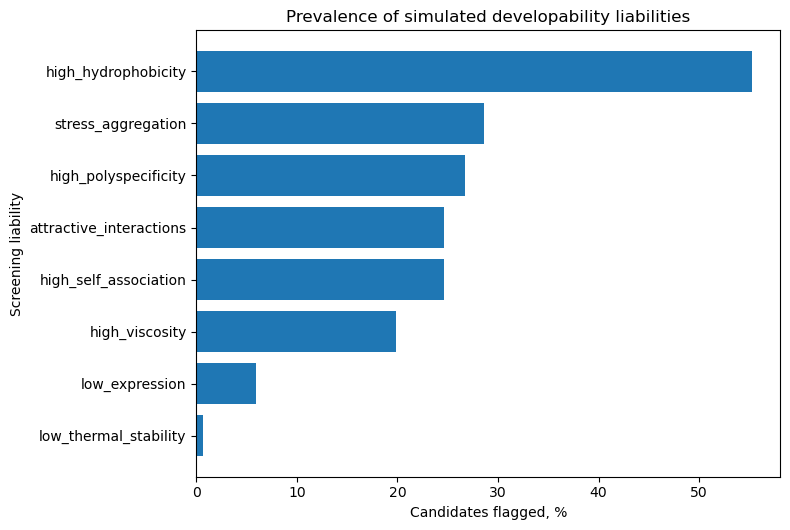

In [81]:
flag_rates = data[flag_columns].mean().sort_values()

plt.figure(figsize=(8.0, 5.4))
plt.barh(flag_rates.index, 100 * flag_rates.values)
plt.xlabel("Candidates flagged, %")
plt.ylabel("Screening liability")
plt.title("Prevalence of simulated developability liabilities")
save_figure("02_liability_prevalence.png")

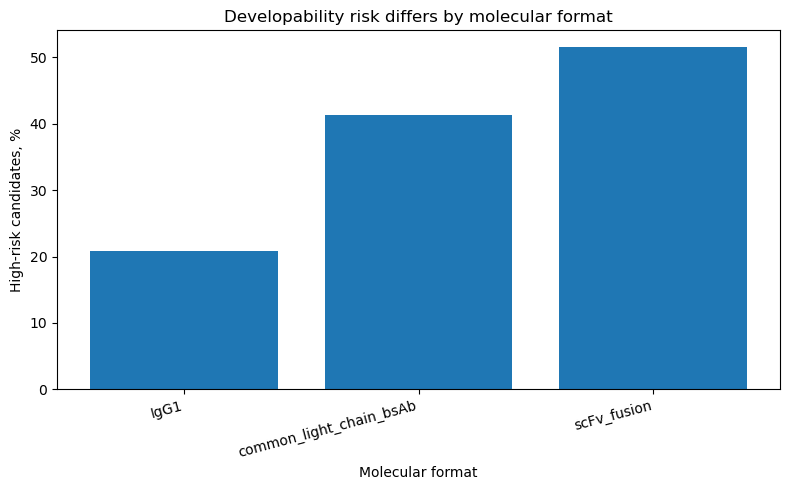

In [82]:
format_risk = data.groupby("molecular_format", observed=True)["high_developability_risk"].mean().sort_values()

plt.figure(figsize=(8.0, 5.0))
plt.bar(format_risk.index, 100 * format_risk.values)
plt.ylabel("High-risk candidates, %")
plt.xlabel("Molecular format")
plt.title("Developability risk differs by molecular format")
plt.xticks(rotation=15, ha="right")
save_figure("03_format_risk.png")

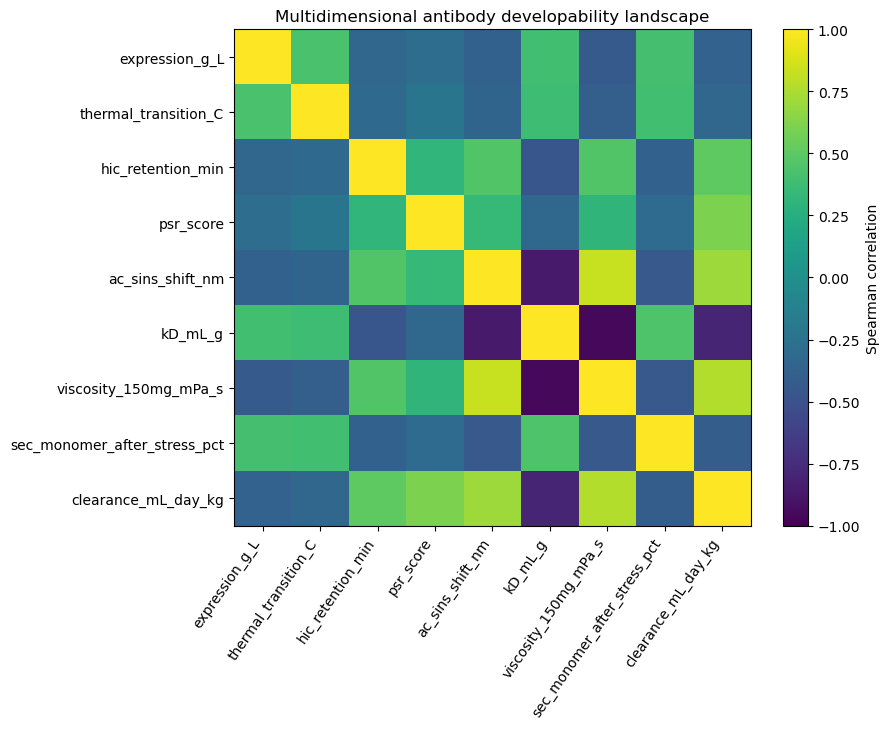

In [83]:
plot_metrics = [
    "expression_g_L", "thermal_transition_C", "hic_retention_min",
    "psr_score", "ac_sins_shift_nm", "kD_mL_g",
    "viscosity_150mg_mPa_s", "sec_monomer_after_stress_pct",
    "clearance_mL_day_kg",
]
corr = data[plot_metrics].corr(method="spearman")

plt.figure(figsize=(9.0, 7.4))
image = plt.imshow(corr.to_numpy(), aspect="auto", vmin=-1, vmax=1)
plt.xticks(range(len(plot_metrics)), plot_metrics, rotation=55, ha="right")
plt.yticks(range(len(plot_metrics)), plot_metrics)
plt.colorbar(image, label="Spearman correlation")
plt.title("Multidimensional antibody developability landscape")
save_figure("04_assay_correlation_heatmap.png")

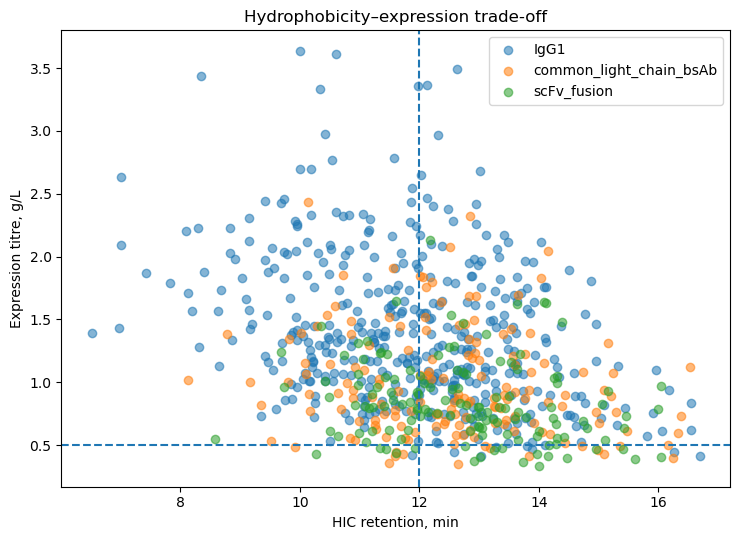

In [84]:
plt.figure(figsize=(7.5, 5.5))
for molecular_format, group in data.groupby("molecular_format", observed=True):
    plt.scatter(group["hic_retention_min"], group["expression_g_L"], alpha=0.55, label=molecular_format)
plt.axvline(12.0, linestyle="--")
plt.axhline(0.50, linestyle="--")
plt.xlabel("HIC retention, min")
plt.ylabel("Expression titre, g/L")
plt.title("Hydrophobicity–expression trade-off")
plt.legend()
save_figure("05_hic_expression_tradeoff.png")

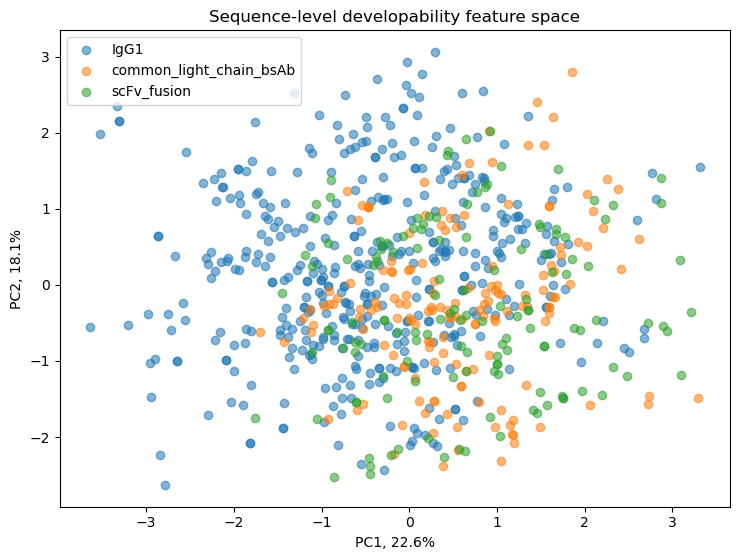

In [85]:
pca_features = [
    "cdrh3_max_length", "cdr_hydrophobic_fraction", "cdr_aromatic_fraction",
    "absolute_charge_proxy", "vh_vl_charge_asymmetry",
    "longest_hydrophobic_run", "total_liability_motifs",
]
scaled = StandardScaler().fit_transform(data[pca_features])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
scores = pca.fit_transform(scaled)

plt.figure(figsize=(7.5, 5.7))
for molecular_format in FORMAT_LEVELS:
    mask = data["molecular_format"].eq(molecular_format)
    plt.scatter(scores[mask, 0], scores[mask, 1], alpha=0.55, label=molecular_format)
plt.xlabel(f"PC1, {100*pca.explained_variance_ratio_[0]:.1f}%")
plt.ylabel(f"PC2, {100*pca.explained_variance_ratio_[1]:.1f}%")
plt.title("Sequence-level developability feature space")
plt.legend()
save_figure("06_sequence_pca.png")

### Interpretation

The simulated matrix contains two major liability axes. HIC, AC-SINS, CSI-BLI, negative kD, viscosity, and stress aggregation reflect self-association. PSR and simulated clearance reflect non-specific interactions. Expression and thermal stability generally move opposite to hydrophobicity and aggregation. Architecture shifts the risk distribution, but there is substantial overlap among formats, so format alone cannot determine candidate progression.

## 6. Statistical comparison among molecular formats

Kruskal–Wallis tests are used because several assay distributions are asymmetric. Epsilon-squared provides an approximate omnibus effect size.

In [88]:
def epsilon_squared_kruskal(H: float, n: int, k: int) -> float:
    return max(0.0, (H - k + 1) / (n - k))

stat_rows = []
for metric in plot_metrics + ["risk_flag_count"]:
    groups = [group[metric].to_numpy() for _, group in data.groupby("molecular_format", observed=True)]
    H, p = stats.kruskal(*groups)
    stat_rows.append({
        "metric": metric,
        "Kruskal_H": H,
        "p_value": p,
        "epsilon_squared": epsilon_squared_kruskal(H, len(data), len(groups)),
    })

format_stats = pd.DataFrame(stat_rows).sort_values("p_value")
display(format_stats)

risk_table = pd.crosstab(data["molecular_format"], data["high_developability_risk"])
chi2, chi_p, dof, expected = stats.chi2_contingency(risk_table)
cramers_v = math.sqrt(chi2 / (risk_table.to_numpy().sum() * (min(risk_table.shape) - 1)))

display(risk_table)
print(f"Chi-square={chi2:.2f}, df={dof}, p={chi_p:.3g}, Cramer's V={cramers_v:.3f}")

,metric,Kruskal_H,p_value,epsilon_squared
0,expression_g_L,140.059223,3.859457e-31,0.192551
6,viscosity_150mg_mPa_s,96.107241,1.350759e-21,0.131251
8,clearance_mL_day_kg,65.775241,5.213002e-15,0.088947
1,thermal_transition_C,65.498966,5.985222e-15,0.088562
9,risk_flag_count,58.990301,1.550311e-13,0.079484
4,ac_sins_shift_nm,51.753660,5.778771e-12,0.069391
5,kD_mL_g,49.831083,1.511185e-11,0.066710
7,sec_monomer_after_stress_pct,30.971802,1.881736e-07,0.040407
2,hic_retention_min,30.854429,1.995473e-07,0.040243
3,psr_score,17.534731,1.557333e-04,0.021666


high_developability_risk,0,1
molecular_format,,
IgG1,336,88
common_light_chain_bsAb,94,66
scFv_fusion,66,70


Chi-square=55.20, df=2, p=1.03e-12, Cramer's V=0.277


## 7. Leakage-resistant predictive modelling

The models use sequence-derived descriptors and format only. Experimental assay columns, latent risk variables, and parent identifiers are excluded. Parent lineages are held out intact.

In [90]:
feature_columns = [
    "molecular_format", "n_parent_mutations", "sequence_length",
    "cdrh3_mean_length", "cdrh3_max_length", "hydrophobic_fraction",
    "cdr_hydrophobic_fraction", "aromatic_fraction", "cdr_aromatic_fraction",
    "positive_fraction", "negative_fraction", "net_charge_proxy",
    "absolute_charge_proxy", "vh_vl_charge_asymmetry",
    "longest_hydrophobic_run", "sequence_entropy",
    "deamidation_motifs", "isomerization_motifs", "oxidation_sites",
    "glycosylation_motifs", "odd_cysteine_warning",
    "total_liability_motifs",
]
categorical_features = ["molecular_format"]
numeric_features = [c for c in feature_columns if c not in categorical_features]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(
    splitter.split(data[feature_columns], data["high_developability_risk"], groups=data["parent_id"])
)
train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()
assert set(train["parent_id"]).isdisjoint(set(test["parent_id"]))

preprocessor = ColumnTransformer([
    ("format", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("numeric", StandardScaler(), numeric_features),
])

classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=180,
        min_samples_leaf=5,
        max_features=0.75,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=1,
    )),
])

classifier.fit(train[feature_columns], train["high_developability_risk"])
test_probability = classifier.predict_proba(test[feature_columns])[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

classification_metrics = {
    "AUROC": roc_auc_score(test["high_developability_risk"], test_probability),
    "Average_precision": average_precision_score(test["high_developability_risk"], test_probability),
    "Brier_score": brier_score_loss(test["high_developability_risk"], test_probability),
}
display(pd.DataFrame([classification_metrics]))
print(classification_report(
    test["high_developability_risk"],
    test_prediction,
    target_names=["lower risk", "high risk"],
    digits=3,
))
display(pd.DataFrame(
    confusion_matrix(test["high_developability_risk"], test_prediction),
    index=["Observed lower", "Observed high"],
    columns=["Predicted lower", "Predicted high"],
))

,AUROC,Average_precision,Brier_score
0,0.828052,0.768641,0.163767


              precision    recall  f1-score   support

  lower risk      0.764     0.855     0.807       110
   high risk      0.719     0.586     0.646        70

    accuracy                          0.750       180
   macro avg      0.742     0.720     0.726       180
weighted avg      0.747     0.750     0.744       180



,Predicted lower,Predicted high
Observed lower,94,16
Observed high,29,41


In [91]:
def bootstrap_auc(y_true, y_prob, n_boot=400, seed=RANDOM_SEED):
    local_rng = np.random.default_rng(seed)
    values = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    for _ in range(n_boot):
        idx = local_rng.integers(0, len(y_true), len(y_true))
        if np.unique(y_true[idx]).size < 2:
            continue
        values.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(values, [2.5, 50, 97.5])

auc_ci = bootstrap_auc(test["high_developability_risk"], test_probability)
print(f"Bootstrap AUROC: median {auc_ci[1]:.3f}, 95% CI {auc_ci[0]:.3f}–{auc_ci[2]:.3f}")

Bootstrap AUROC: median 0.830, 95% CI 0.761–0.887


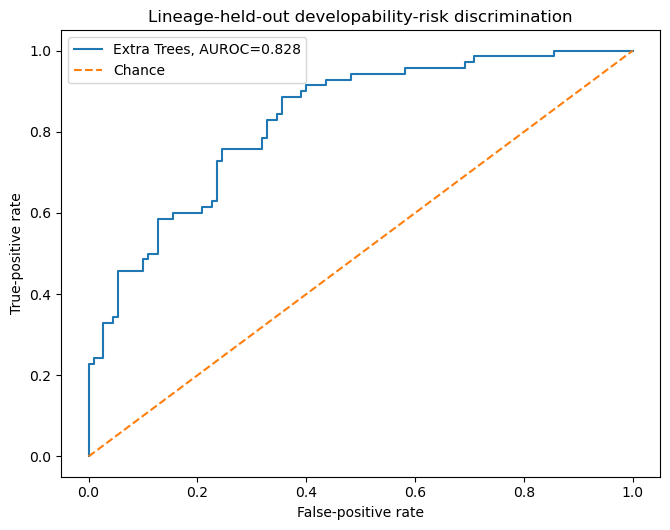

In [92]:
fpr, tpr, _ = roc_curve(test["high_developability_risk"], test_probability)

plt.figure(figsize=(6.8, 5.4))
plt.plot(fpr, tpr, label=f"Extra Trees, AUROC={classification_metrics['AUROC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("Lineage-held-out developability-risk discrimination")
plt.legend()
save_figure("07_roc_curve.png")

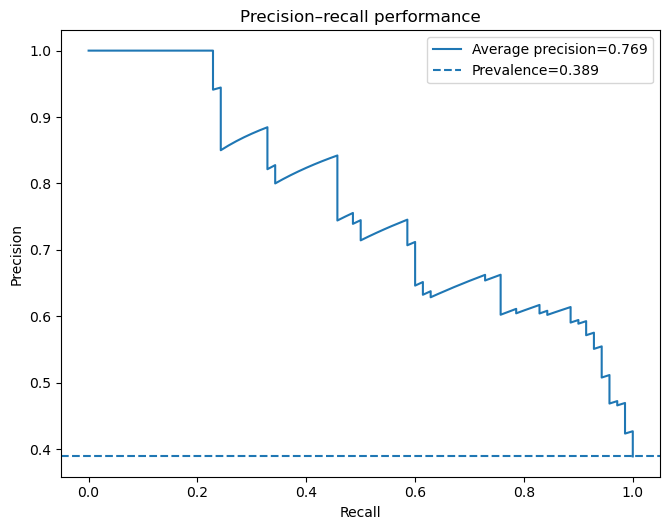

In [93]:
precision, recall, _ = precision_recall_curve(test["high_developability_risk"], test_probability)
baseline = test["high_developability_risk"].mean()

plt.figure(figsize=(6.8, 5.4))
plt.plot(recall, precision, label=f"Average precision={classification_metrics['Average_precision']:.3f}")
plt.axhline(baseline, linestyle="--", label=f"Prevalence={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–recall performance")
plt.legend()
save_figure("08_precision_recall_curve.png")

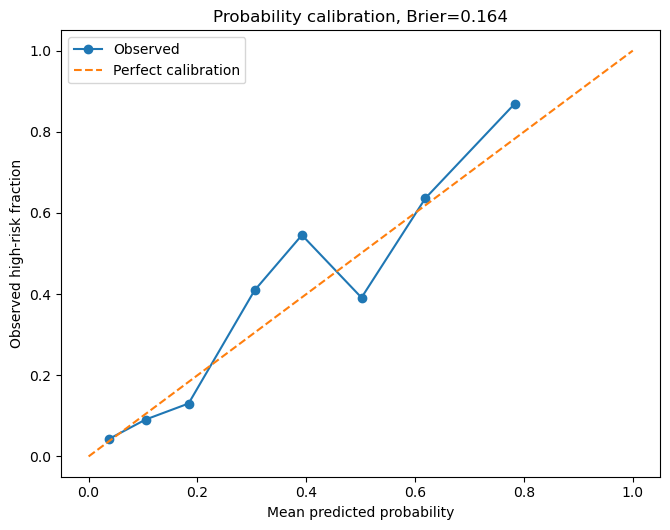

In [94]:
fraction_positive, mean_predicted = calibration_curve(
    test["high_developability_risk"], test_probability, n_bins=8, strategy="quantile"
)

plt.figure(figsize=(6.8, 5.4))
plt.plot(mean_predicted, fraction_positive, marker="o", label="Observed")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed high-risk fraction")
plt.title(f"Probability calibration, Brier={classification_metrics['Brier_score']:.3f}")
plt.legend()
save_figure("09_calibration_curve.png")

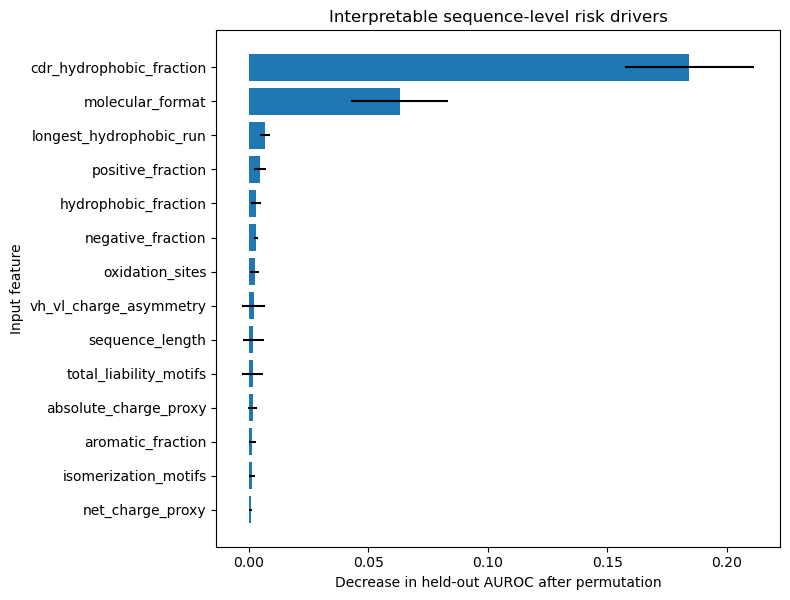

,feature,importance_mean,importance_sd
6,cdr_hydrophobic_fraction,0.184302,0.027160
0,molecular_format,0.063084,0.020310
14,longest_hydrophobic_run,0.006672,0.002193
9,positive_fraction,0.004497,0.002570
5,hydrophobic_fraction,0.002825,0.002069
10,negative_fraction,0.002825,0.000866
18,oxidation_sites,0.002386,0.001876
13,vh_vl_charge_asymmetry,0.001932,0.004885
2,sequence_length,0.001899,0.004274
21,total_liability_motifs,0.001623,0.004355


In [95]:
perm = permutation_importance(
    classifier,
    test[feature_columns],
    test["high_developability_risk"],
    scoring="roc_auc",
    n_repeats=8,
    random_state=RANDOM_SEED,
    n_jobs=1,
)
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

top_importance = importance.head(14).sort_values("importance_mean")
plt.figure(figsize=(8.0, 6.1))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_sd"],
)
plt.xlabel("Decrease in held-out AUROC after permutation")
plt.ylabel("Input feature")
plt.title("Interpretable sequence-level risk drivers")
save_figure("10_permutation_importance.png")

display(importance.head(14))

### Multi-output assay prediction

A separate model estimates expression, thermal transition, HIC, PSR, and AC-SINS from the same pre-assay inputs.

In [97]:
regression_targets = [
    "expression_g_L",
    "thermal_transition_C",
    "hic_retention_min",
    "psr_score",
    "ac_sins_shift_nm",
]

regressor = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", ExtraTreesRegressor(
        n_estimators=180,
        min_samples_leaf=4,
        max_features=0.80,
        random_state=RANDOM_SEED,
        n_jobs=1,
    )),
])

regressor.fit(train[feature_columns], train[regression_targets])
test_reg_pred = regressor.predict(test[feature_columns])

regression_rows = []
for j, target in enumerate(regression_targets):
    regression_rows.append({
        "target": target,
        "MAE": mean_absolute_error(test[target], test_reg_pred[:, j]),
        "R2": r2_score(test[target], test_reg_pred[:, j]),
        "Spearman_r": stats.spearmanr(test[target], test_reg_pred[:, j]).statistic,
    })
regression_metrics = pd.DataFrame(regression_rows)
display(regression_metrics)

,target,MAE,R2,Spearman_r
0,expression_g_L,0.342126,0.432107,0.705663
1,thermal_transition_C,1.727168,0.199258,0.477739
2,hic_retention_min,0.995154,0.402299,0.626948
3,psr_score,0.124598,0.184543,0.454633
4,ac_sins_shift_nm,1.493324,0.321510,0.618141


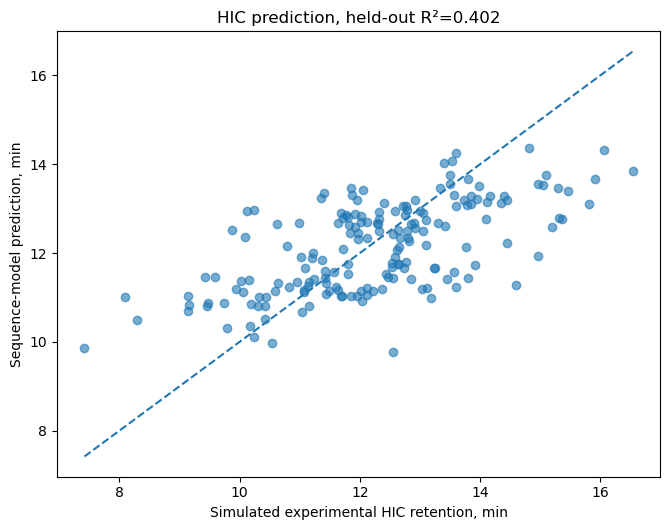

In [98]:
target_to_plot = "hic_retention_min"
target_index = regression_targets.index(target_to_plot)
target_r2 = regression_metrics.loc[regression_metrics["target"].eq(target_to_plot), "R2"].iloc[0]

plt.figure(figsize=(6.8, 5.4))
plt.scatter(test[target_to_plot], test_reg_pred[:, target_index], alpha=0.6)
lims = [
    min(test[target_to_plot].min(), test_reg_pred[:, target_index].min()),
    max(test[target_to_plot].max(), test_reg_pred[:, target_index].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Simulated experimental HIC retention, min")
plt.ylabel("Sequence-model prediction, min")
plt.title(f"HIC prediction, held-out R²={target_r2:.3f}")
save_figure("11_hic_predicted_vs_observed.png")

In [99]:
format_performance = []
test_scored = test.assign(predicted_risk=test_probability)

for molecular_format, group in test_scored.groupby("molecular_format", observed=True):
    auc = np.nan
    if group["high_developability_risk"].nunique() == 2:
        auc = roc_auc_score(group["high_developability_risk"], group["predicted_risk"])
    format_performance.append({
        "molecular_format": molecular_format,
        "n": len(group),
        "prevalence": group["high_developability_risk"].mean(),
        "AUROC": auc,
        "Brier_score": brier_score_loss(group["high_developability_risk"], group["predicted_risk"]),
    })

format_performance_df = pd.DataFrame(format_performance)
display(format_performance_df)

,molecular_format,n,prevalence,AUROC,Brier_score
0,IgG1,96,0.229167,0.846437,0.125195
1,common_light_chain_bsAb,44,0.545455,0.666667,0.231974
2,scFv_fusion,40,0.600000,0.817708,0.181309


A useful early developability model must be judged on enrichment, calibration, probability error, lineage-held-out generalisation, and format-stratified robustness, not AUROC alone. Even a strong model should prioritise experiments rather than replace HIC, polyspecificity, self-interaction, stability, expression, viscosity, and formulation measurements.

## 8. Experimental value of information

Candidates are ranked by predicted risk. The enrichment curve asks how efficiently a limited laboratory budget captures genuinely high-risk molecules.

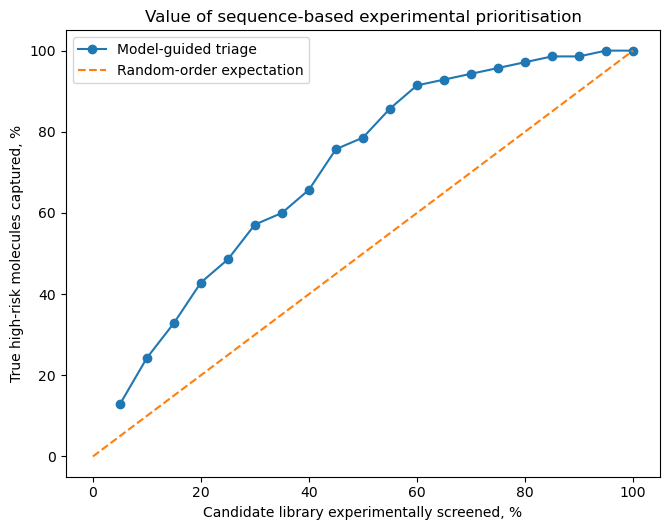

Screening approximately 25% of the held-out library captures 48.6% of high-risk molecules.


In [102]:
triage = test[["candidate_id", "high_developability_risk"]].copy()
triage["predicted_risk"] = test_probability
triage = triage.sort_values("predicted_risk", ascending=False).reset_index(drop=True)

budget_rows = []
for fraction_screened in np.linspace(0.05, 1.0, 20):
    n_screen = max(1, int(round(len(triage) * fraction_screened)))
    found = triage.head(n_screen)["high_developability_risk"].sum()
    total = triage["high_developability_risk"].sum()
    budget_rows.append({
        "fraction_screened": fraction_screened,
        "fraction_high_risk_captured": found / max(total, 1),
    })
budget_curve = pd.DataFrame(budget_rows)

plt.figure(figsize=(6.8, 5.4))
plt.plot(
    100 * budget_curve["fraction_screened"],
    100 * budget_curve["fraction_high_risk_captured"],
    marker="o",
    label="Model-guided triage",
)
plt.plot([0, 100], [0, 100], linestyle="--", label="Random-order expectation")
plt.xlabel("Candidate library experimentally screened, %")
plt.ylabel("True high-risk molecules captured, %")
plt.title("Value of sequence-based experimental prioritisation")
plt.legend()
save_figure("12_value_of_information.png")

at_25 = budget_curve.iloc[(budget_curve["fraction_screened"] - 0.25).abs().argmin()]
print(
    f"Screening approximately 25% of the held-out library captures "
    f"{100*at_25['fraction_high_risk_captured']:.1f}% of high-risk molecules."
)

## 9. Targeted engineering of a high-affinity, high-risk lead

The objective is to reduce predicted overall risk, HIC retention, polyspecificity, and self-association while improving expression and thermal stability, preserving affinity, and limiting the number of substitutions.

In [104]:
candidate_pool = data[
    (data["high_developability_risk"] == 1)
    & (data["kd_nM"] <= data["kd_nM"].quantile(0.25))
].copy()

lead = candidate_pool.sort_values(
    ["cdr_hydrophobic_fraction", "risk_flag_count", "kd_nM"],
    ascending=[False, False, True],
).iloc[0]

display(lead[[
    "candidate_id", "parent_id", "molecular_format", "cdrh3_a", "cdrh3_b",
    "kd_nM", "risk_flag_count", "expression_g_L", "thermal_transition_C",
    "hic_retention_min", "psr_score", "ac_sins_shift_nm",
]].to_frame("starting_lead"))

,starting_lead
candidate_id,P053_V2
parent_id,P053
molecular_format,scFv_fusion
cdrh3_a,RIALVVLKFGLYWERIIPM
cdrh3_b,LLMINGLFLHFK
kd_nM,0.521471
risk_flag_count,6
expression_g_L,0.993864
thermal_transition_C,64.871286
hic_retention_min,14.296261


In [105]:
def targeted_cdr_mutation(seq: str, n_mutations: int, local_rng: np.random.Generator):
    chars = list(seq)
    risky_positions = [i for i, aa in enumerate(chars) if aa in HYDROPHOBIC.union(set("KR"))]
    if not risky_positions:
        risky_positions = list(range(len(chars)))
    chosen = local_rng.choice(
        risky_positions,
        size=min(n_mutations, len(risky_positions)),
        replace=False,
    )
    changes = []
    aromatic_replacements = 0
    for pos in chosen:
        old = chars[pos]
        choices = POLAR_SAFE[POLAR_SAFE != old]
        new = str(local_rng.choice(choices))
        chars[pos] = new
        changes.append(f"{old}{pos + 1}{new}")
        aromatic_replacements += int(old in AROMATIC)
    return "".join(chars), changes, aromatic_replacements

design_rng = np.random.default_rng(RANDOM_SEED + 91)
variant_rows = []
lead_dict = lead.to_dict()

for variant_index in range(300):
    n_mutations = int(design_rng.choice([2, 3, 4, 5], p=[0.20, 0.35, 0.30, 0.15]))
    new_cdr_a, changes_a, aromatic_a = targeted_cdr_mutation(
        lead["cdrh3_a"], n_mutations, design_rng
    )

    if lead["molecular_format"] == "IgG1":
        new_cdr_b = new_cdr_a
        changes_b = []
        aromatic_b = 0
    else:
        if design_rng.random() < 0.38:
            new_cdr_b, changes_b, aromatic_b = targeted_cdr_mutation(
                lead["cdrh3_b"], max(1, n_mutations - 1), design_rng
            )
        else:
            new_cdr_b, changes_b, aromatic_b = lead["cdrh3_b"], [], 0

    row = lead_dict.copy()
    row["candidate_id"] = f"{lead['candidate_id']}_ENG{variant_index + 1:03d}"
    row["cdrh3_a"] = new_cdr_a
    row["cdrh3_b"] = new_cdr_b
    row["vh_a"] = lead["vh_a"].replace(lead["cdrh3_a"], new_cdr_a, 1)
    row["vh_b"] = (
        row["vh_a"]
        if lead["molecular_format"] == "IgG1"
        else lead["vh_b"].replace(lead["cdrh3_b"], new_cdr_b, 1)
    )
    row["n_parent_mutations"] = lead["n_parent_mutations"] + len(changes_a) + len(changes_b)
    row["engineering_changes"] = ";".join(changes_a + changes_b)
    row["engineering_mutation_count"] = len(changes_a) + len(changes_b)
    row["aromatic_replacements"] = aromatic_a + aromatic_b
    row.update(sequence_descriptors(pd.Series(row)))
    variant_rows.append(row)

designed = pd.DataFrame(variant_rows)
designed["predicted_high_risk_probability"] = classifier.predict_proba(designed[feature_columns])[:, 1]

designed_reg = regressor.predict(designed[feature_columns])
for j, target in enumerate(regression_targets):
    designed[f"predicted_{target}"] = designed_reg[:, j]

designed["predicted_kd_nM"] = np.clip(
    lead["kd_nM"] * np.exp(
        0.10 * designed["engineering_mutation_count"]
        + 0.32 * designed["aromatic_replacements"]
        + design_rng.normal(0, 0.10, len(designed))
    ),
    0.03, 500,
)

def minmax(series):
    denominator = series.max() - series.min()
    if denominator == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / denominator

designed["design_utility"] = (
    0.30 * minmax(designed["predicted_high_risk_probability"])
    + 0.13 * minmax(designed["predicted_hic_retention_min"])
    + 0.10 * minmax(designed["predicted_psr_score"])
    + 0.22 * minmax(designed["predicted_kd_nM"])
    + 0.07 * minmax(-designed["predicted_expression_g_L"])
    + 0.05 * minmax(-designed["predicted_thermal_transition_C"])
    + 0.13 * minmax(designed["engineering_mutation_count"])
)

def pareto_front_2d(frame, x, y):
    order = frame.sort_values([x, y]).index
    best_y = np.inf
    selected = []
    for idx in order:
        current_y = frame.loc[idx, y]
        if current_y < best_y:
            selected.append(idx)
            best_y = current_y
    return pd.Index(selected)

pareto_index = pareto_front_2d(
    designed,
    "predicted_high_risk_probability",
    "predicted_kd_nM",
)
designed["pareto_optimal"] = designed.index.isin(pareto_index)

conservative_designs = designed[designed["engineering_mutation_count"] <= 5].copy()
shortlist = conservative_designs.sort_values(
    ["design_utility", "engineering_mutation_count"],
    ascending=[True, True],
).head(15).copy()

display(shortlist[[
    "candidate_id", "engineering_changes", "engineering_mutation_count",
    "predicted_high_risk_probability", "predicted_expression_g_L",
    "predicted_thermal_transition_C", "predicted_hic_retention_min",
    "predicted_psr_score", "predicted_ac_sins_shift_nm",
    "predicted_kd_nM", "pareto_optimal", "design_utility",
]])

,candidate_id,engineering_changes,engineering_mutation_count,predicted_high_risk_probability,predicted_expression_g_L,predicted_thermal_transition_C,predicted_hic_retention_min,predicted_psr_score,predicted_ac_sins_shift_nm,predicted_kd_nM,pareto_optimal,design_utility
24,P053_V2_ENG025,M19T;A3S;V5Q;M3G;F8E,5,0.599526,0.903844,68.991210,13.110096,0.567338,8.422570,1.033972,True,0.325544
74,P053_V2_ENG075,A3Q;V5G;L7D;L1E;L7D,5,0.601439,0.850501,68.411760,13.098915,0.567393,8.639301,0.748005,True,0.330864
122,P053_V2_ENG123,I17D;A3T;L4G;V5G;I16N,5,0.601084,0.856079,68.376950,13.099278,0.567453,8.626198,0.777079,True,0.331513
159,P053_V2_ENG160,V6S;W13S;L7D;L9D;F11D,5,0.600403,0.911680,69.249728,13.039261,0.568014,8.410487,1.407706,False,0.336813
138,P053_V2_ENG139,I2G;M19N;L11T;F8Q;M3G,5,0.601092,0.900572,68.954650,13.118303,0.568835,8.480438,1.249228,False,0.342315
170,P053_V2_ENG171,L11Q;I2T;I16G;L9T;I4Q,5,0.612275,0.857116,68.337536,13.120682,0.569427,8.670137,0.773544,False,0.344211
160,P053_V2_ENG161,W13D;I16N;I2E;L9Q;I4N,5,0.597964,0.890235,68.925680,13.127025,0.567710,8.491393,1.302757,False,0.344966
69,P053_V2_ENG070,W13N;I2Q;V5T;L9G;L2D,5,0.609108,0.891310,68.911398,13.113702,0.569051,8.501858,1.201136,False,0.348447
125,P053_V2_ENG126,M19S;L7N;A3Q;L9Q;F11Q,5,0.610675,0.889113,68.887545,13.118549,0.570328,8.539738,1.236755,False,0.354354
296,P053_V2_ENG297,I16Q;I17G;Y12D;M3N;L7T,5,0.614788,0.895698,68.948273,13.220897,0.572992,8.547941,1.220971,False,0.365243


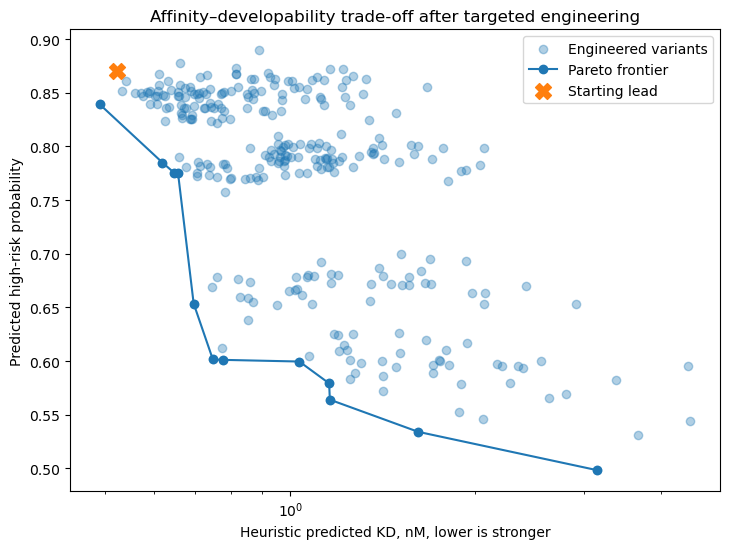

In [106]:
plt.figure(figsize=(7.4, 5.6))
plt.scatter(
    designed["predicted_kd_nM"],
    designed["predicted_high_risk_probability"],
    alpha=0.35,
    label="Engineered variants",
)
pareto = designed[designed["pareto_optimal"]].sort_values("predicted_kd_nM")
plt.plot(
    pareto["predicted_kd_nM"],
    pareto["predicted_high_risk_probability"],
    marker="o",
    label="Pareto frontier",
)
lead_risk_probability = classifier.predict_proba(pd.DataFrame([lead])[feature_columns])[:, 1][0]
plt.scatter(
    [lead["kd_nM"]],
    [lead_risk_probability],
    marker="X",
    s=130,
    label="Starting lead",
)
plt.xscale("log")
plt.xlabel("Heuristic predicted KD, nM, lower is stronger")
plt.ylabel("Predicted high-risk probability")
plt.title("Affinity–developability trade-off after targeted engineering")
plt.legend()
save_figure("13_variant_pareto_front.png")

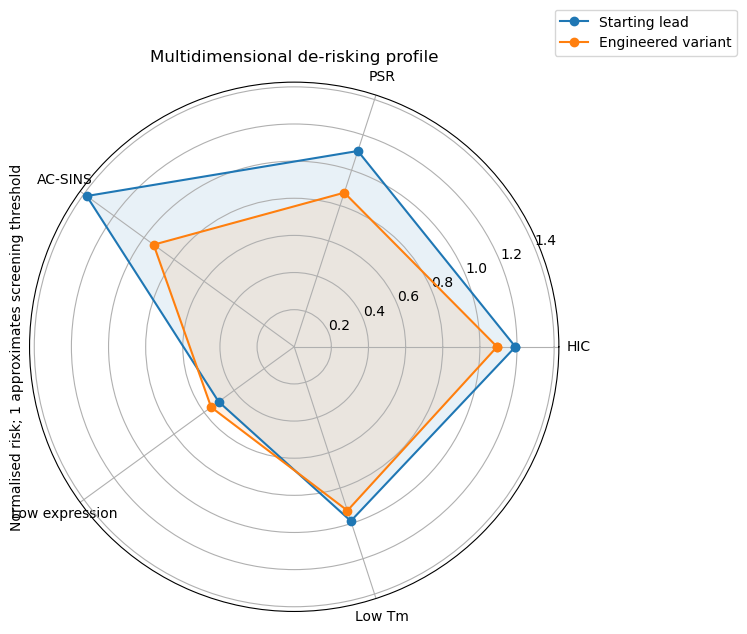

In [107]:
best_variant = shortlist.iloc[0]

risk_axes = [
    ("HIC", lead["hic_retention_min"] / 12.0, best_variant["predicted_hic_retention_min"] / 12.0),
    ("PSR", lead["psr_score"] / 0.65, best_variant["predicted_psr_score"] / 0.65),
    ("AC-SINS", lead["ac_sins_shift_nm"] / 9.0, best_variant["predicted_ac_sins_shift_nm"] / 9.0),
    ("Low expression", 0.50 / lead["expression_g_L"], 0.50 / best_variant["predicted_expression_g_L"]),
    ("Low Tm", 64.0 / lead["thermal_transition_C"], 64.0 / best_variant["predicted_thermal_transition_C"]),
]
labels = [row[0] for row in risk_axes]
lead_values = np.array([row[1] for row in risk_axes])
variant_values = np.array([row[2] for row in risk_axes])
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles_closed = np.r_[angles, angles[0]]

plt.figure(figsize=(7.0, 6.4))
ax = plt.subplot(111, polar=True)
ax.plot(angles_closed, np.r_[lead_values, lead_values[0]], marker="o", label="Starting lead")
ax.fill(angles_closed, np.r_[lead_values, lead_values[0]], alpha=0.10)
ax.plot(angles_closed, np.r_[variant_values, variant_values[0]], marker="o", label="Engineered variant")
ax.fill(angles_closed, np.r_[variant_values, variant_values[0]], alpha=0.10)
ax.set_xticks(angles)
ax.set_xticklabels(labels)
ax.set_ylabel("Normalised risk; 1 approximates screening threshold")
ax.set_title("Multidimensional de-risking profile")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
save_figure("14_lead_vs_engineered_radar.png")

The Pareto frontier contains variants for which no other generated molecule has both lower predicted risk and stronger predicted affinity. The selected sequence is a rational construct for experimental testing, not a validated superior molecule. A production workflow should add antigen-bound modelling, antibody numbering, germline context, surface-patch calculations, immunogenicity assessment, chain-pairing analysis, expression, affinity, SEC, HIC, thermal stability, AC-SINS, polyspecificity, and viscosity experiments.

## 10. Illustrative expression-construct outputs

The selected variable domains are reverse-translated with a compact human-preferred codon table. These outputs omit signal peptides, constant regions, regulatory elements, vector backbone, assembly sites, secretion optimisation, and manufacturability review.

In [110]:
HUMAN_PREFERRED_CODON = {
    "A":"GCC","C":"TGC","D":"GAC","E":"GAG","F":"TTC",
    "G":"GGC","H":"CAC","I":"ATC","K":"AAG","L":"CTG",
    "M":"ATG","N":"AAC","P":"CCC","Q":"CAG","R":"CGC",
    "S":"AGC","T":"ACC","V":"GTG","W":"TGG","Y":"TAC",
}

def reverse_translate(aa_sequence: str) -> str:
    return "".join(HUMAN_PREFERRED_CODON[aa] for aa in aa_sequence)

def gc_fraction(dna: str) -> float:
    return (dna.count("G") + dna.count("C")) / len(dna)

construct_rows = []
for chain_name in ["vh_a", "vh_b", "vl"]:
    aa = best_variant[chain_name]
    dna = reverse_translate(aa)
    construct_rows.append({
        "candidate_id": best_variant["candidate_id"],
        "chain": chain_name,
        "amino_acids": len(aa),
        "coding_bp": len(dna),
        "GC_fraction": gc_fraction(dna),
        "amino_acid_sequence": aa,
        "illustrative_coding_sequence": dna,
    })

constructs = pd.DataFrame(construct_rows)
display(constructs[["candidate_id", "chain", "amino_acids", "coding_bp", "GC_fraction"]])

fasta_path = OUTPUT_DIR / "top_engineered_variant_variable_domains.fasta"
with fasta_path.open("w") as handle:
    for _, row in constructs.iterrows():
        handle.write(f">{row['candidate_id']}|{row['chain']}|AA\n")
        handle.write(row["amino_acid_sequence"] + "\n")
        handle.write(f">{row['candidate_id']}|{row['chain']}|illustrative_human_coding_DNA\n")
        handle.write(row["illustrative_coding_sequence"] + "\n")

print(f"Wrote {fasta_path}")

,candidate_id,chain,amino_acids,coding_bp,GC_fraction
0,P053_V2_ENG025,vh_a,118,354,0.655367
1,P053_V2_ENG025,vh_b,111,333,0.645646
2,P053_V2_ENG025,vl,101,303,0.636964


Wrote antibody_design_outputs/top_engineered_variant_variable_domains.fasta


## 11. Automated scientific interpretation

In [112]:
best_format = format_risk.idxmin()
worst_format = format_risk.idxmax()
top_driver = importance.iloc[0]["feature"]

# Create a writable NumPy copy of the absolute correlation matrix.
corr_abs_array = corr.abs().to_numpy(copy=True)

# Exclude the diagonal and the duplicated lower triangle.
upper_triangle_mask = np.triu(
    np.ones(corr_abs_array.shape, dtype=bool),
    k=1,
)

masked_corr = np.where(upper_triangle_mask, corr_abs_array, np.nan)

row_idx, col_idx = np.unravel_index(
    np.nanargmax(masked_corr),
    masked_corr.shape,
)

strongest_corr_pair = (
    corr.index[row_idx],
    corr.columns[col_idx],
    corr.iloc[row_idx, col_idx],
)

risk_reduction = (
    lead_risk_probability
    - best_variant["predicted_high_risk_probability"]
)

interpretation = f"""
KEY RESULTS

1. The synthetic library contains {len(data)} candidates from \
{data["parent_id"].nunique()} independent parent lineages.

2. High developability risk prevalence is \
{100 * data["high_developability_risk"].mean():.1f}%.

3. The lowest format-level risk is observed for {best_format}; \
the highest is observed for {worst_format}.

4. The strongest absolute assay correlation is between \
{strongest_corr_pair[0]} and {strongest_corr_pair[1]} \
(Spearman r={strongest_corr_pair[2]:.2f}).

5. The lineage-held-out classifier achieves \
AUROC={classification_metrics["AUROC"]:.3f}, \
average precision={classification_metrics["Average_precision"]:.3f}, \
and Brier score={classification_metrics["Brier_score"]:.3f}.

6. The most influential pre-assay feature by permutation importance \
is {top_driver}.

7. The selected engineered variant changes \
{int(best_variant["engineering_mutation_count"])} CDR residue(s).

8. Predicted high-risk probability changes from \
{lead_risk_probability:.3f} to \
{best_variant["predicted_high_risk_probability"]:.3f}, \
an absolute reduction of {risk_reduction:.3f}.

9. The selected variant has a heuristic predicted KD of \
{best_variant["predicted_kd_nM"]:.3f} nM compared with \
{lead["kd_nM"]:.3f} nM for the starting lead.

SCIENTIFIC IMPLICATION

The results illustrate a design–build–test strategy in which sequence-based
models reduce the experimental search space, but orthogonal laboratory
measurements remain decisive. Multi-objective optimisation is preferable to
maximising affinity alone because hydrophobicity, self-association,
polyspecificity, stability, expression, viscosity, and format complexity can
become independent bottlenecks.

Grouped validation is essential because variant-level random splitting would
overestimate performance by allowing related sequences on both sides of the
evaluation.
"""

print(interpretation)


KEY RESULTS

1. The synthetic library contains 720 candidates from 180 independent parent lineages.

2. High developability risk prevalence is 31.1%.

3. The lowest format-level risk is observed for IgG1; the highest is observed for scFv_fusion.

4. The strongest absolute assay correlation is between kD_mL_g and viscosity_150mg_mPa_s (Spearman r=-0.95).

5. The lineage-held-out classifier achieves AUROC=0.828, average precision=0.769, and Brier score=0.164.

6. The most influential pre-assay feature by permutation importance is cdr_hydrophobic_fraction.

7. The selected engineered variant changes 5 CDR residue(s).

8. Predicted high-risk probability changes from 0.871 to 0.600, an absolute reduction of 0.271.

9. The selected variant has a heuristic predicted KD of 1.034 nM compared with 0.521 nM for the starting lead.

SCIENTIFIC IMPLICATION

The results illustrate a design–build–test strategy in which sequence-based
models reduce the experimental search space, but orthogonal laborat

## 12. Export reproducible outputs

In [114]:
export_exclude = ["risk_propensity_latent", "hidden_process_risk", "base_log10_kd"]
export_data = data.drop(columns=export_exclude)

dataset_path = OUTPUT_DIR / "synthetic_antibody_developability_dataset.csv"
performance_path = OUTPUT_DIR / "model_performance.csv"
shortlist_path = OUTPUT_DIR / "engineered_variant_shortlist.csv"
threshold_path = OUTPUT_DIR / "screening_thresholds.json"
manifest_path = OUTPUT_DIR / "manifest.json"

export_data.to_csv(dataset_path, index=False)

performance_table = pd.concat([
    pd.DataFrame([{"task": "classification", **classification_metrics}]),
    regression_metrics.assign(task="regression"),
], ignore_index=True, sort=False)
performance_table.to_csv(performance_path, index=False)

shortlist_export_columns = [
    "candidate_id", "molecular_format", "cdrh3_a", "cdrh3_b",
    "engineering_changes", "engineering_mutation_count",
    "predicted_high_risk_probability", "predicted_expression_g_L",
    "predicted_thermal_transition_C", "predicted_hic_retention_min",
    "predicted_psr_score", "predicted_ac_sins_shift_nm",
    "predicted_kd_nM", "pareto_optimal", "design_utility",
]
shortlist[shortlist_export_columns].to_csv(shortlist_path, index=False)

with threshold_path.open("w") as handle:
    json.dump(thresholds, handle, indent=2)

manifest = {
    "random_seed": RANDOM_SEED,
    "n_candidates": int(len(data)),
    "n_parent_lineages": int(data["parent_id"].nunique()),
    "files": {
        "dataset": str(dataset_path),
        "model_performance": str(performance_path),
        "engineered_shortlist": str(shortlist_path),
        "fasta": str(fasta_path),
        "thresholds": str(threshold_path),
        "figures_directory": str(FIGURE_DIR),
    },
    "scientific_status": "Synthetic demonstration; not experimentally validated.",
}
with manifest_path.open("w") as handle:
    json.dump(manifest, handle, indent=2)

for path in [dataset_path, performance_path, shortlist_path, fasta_path, threshold_path, manifest_path]:
    print(path, path.stat().st_size, "bytes")

antibody_design_outputs/synthetic_antibody_developability_dataset.csv 679612 bytes
antibody_design_outputs/model_performance.csv 582 bytes
antibody_design_outputs/engineered_variant_shortlist.csv 3886 bytes
antibody_design_outputs/top_engineered_variant_variable_domains.fasta 1547 bytes
antibody_design_outputs/screening_thresholds.json 595 bytes
antibody_design_outputs/manifest.json 645 bytes


## 13. Limitations and next experimental steps

### Limitations

1. The sequences and measurements are synthetic.
2. Sequence proxies replace experimentally determined structures and conformational ensembles.
3. CDR definitions are simulated rather than generated by an antibody-numbering tool.
4. Liability motifs are not filtered by solvent exposure or local structure.
5. Affinity preservation is a transparent heuristic, not an antigen-aware prediction.
6. The data-generating process is simpler than real discovery data.
7. Thresholds are illustrative screening rules, not release specifications.
8. Composite risk labels partly reflect the rules used to generate them.
9. Correlations among simulated outputs do not establish causality.

### Recommended design–build–test cycle

1. Express the parent and Pareto-ranked variants in the intended format.
2. Confirm identity, purity, intact mass, chain pairing, and aggregation state.
3. Measure target affinity and functional potency before accepting a developability improvement.
4. Run orthogonal assays for HIC, self-interaction, polyspecificity, thermal stability, stress aggregation, and viscosity.
5. Include low-risk and high-risk reference antibodies on each plate.
6. Model batch, plate, operator, and day effects.
7. Retrain with uncertainty-aware active learning, reserving parent lineages and projects for external validation.
8. Link each computational liability to an experimental confirmation and engineering decision.

## References

1. Jain T, et al. Biophysical properties of the clinical-stage antibody landscape. *Proc Natl Acad Sci U S A*. 2017;114:944–949. doi: [10.1073/pnas.1616408114](https://doi.org/10.1073/pnas.1616408114). PMID: [28096333](https://pubmed.ncbi.nlm.nih.gov/28096333/).
2. Raybould MIJ, et al. Five computational developability guidelines for therapeutic antibody profiling. *Proc Natl Acad Sci U S A*. 2019;116:4025–4030. doi: [10.1073/pnas.1810576116](https://doi.org/10.1073/pnas.1810576116). PMID: [30765520](https://pubmed.ncbi.nlm.nih.gov/30765520/).
3. Lauer TM, et al. Developability index: a rapid in silico tool for the screening of antibody aggregation propensity. *J Pharm Sci*. 2012;101:102–115. PMID: [21935950](https://pubmed.ncbi.nlm.nih.gov/21935950/).
4. Jetha A, et al. Homology modeling and structure-based design improve hydrophobic interaction chromatography behavior of integrin α11-binding antibodies. *mAbs*. 2018. PMID: [30110240](https://pubmed.ncbi.nlm.nih.gov/30110240/).
5. Bailly M, et al. Predicting antibody developability profiles through early stage discovery screening. *mAbs*. 2020;12:1743053. doi: [10.1080/19420862.2020.1743053](https://doi.org/10.1080/19420862.2020.1743053). PMID: [32249670](https://pubmed.ncbi.nlm.nih.gov/32249670/).
6. Zhang Y, et al. Physicochemical rules for identifying monoclonal antibodies with drug-like specificity. *Mol Pharm*. 2020;17:2555–2569. PMID: [32453957](https://pubmed.ncbi.nlm.nih.gov/32453957/).
7. Grinshpun B, et al. Identifying biophysical assays and in silico properties that enrich for slow clearance in clinical-stage therapeutic antibodies. *mAbs*. 2021;13:1932230. PMID: [34116620](https://pubmed.ncbi.nlm.nih.gov/34116620/).
8. Datta-Mannan A, et al. Pharmacokinetic developability and disposition profiles of bispecific antibodies. *mAbs*. 2022. PMID: [35076469](https://pubmed.ncbi.nlm.nih.gov/35076469/).
9. Park E, et al. Molecular surface descriptors to predict antibody developability. *mAbs*. 2024. PMID: [38853585](https://pubmed.ncbi.nlm.nih.gov/38853585/).
10. Condado-Morales I, et al. Comparative developability of full-length antibodies and different antibody formats. *mAbs*. 2024. PMID: [39364796](https://pubmed.ncbi.nlm.nih.gov/39364796/).